# 03 — Modeling: Predicting Loan Default

This notebook builds and evaluates machine learning models (Logistic Regression, Decision Tree, Random Forest) to predict loan default using borrower demographic, financial, and loan-related features.


In [8]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

In [10]:
# Loading the dataset
df = pd.read_csv("C:/Users/user/Loan_default_predictor/data/clean/Loan_default_clean.csv")
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,1,1,Other,1,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,0,0,Other,1,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,1,1,Auto,0,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,0,0,Business,0,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,0,1,Auto,0,0


In [11]:
# Defining features and target variable
target_col = "Default"
y = df[target_col]

X = df.drop(columns=[target_col, "LoanID"])  # LoanID is just an identifier
X.head()


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,1,1,Other,1
1,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,0,0,Other,1
2,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,1,1,Auto,0
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,0,0,Business,0
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,0,1,Auto,0


In [12]:
# Identifying numerical and categorical features
numeric_features = ['Age','Income','LoanAmount','CreditScore',
                    'MonthsEmployed','NumCreditLines',
                    'InterestRate','LoanTerm','DTIRatio',
                    'HasMortgage','HasDependents','HasCoSigner']

categorical_features = ['Education','EmploymentType','MaritalStatus','LoanPurpose']


In [13]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape


((3999, 16), (1000, 16))

In [14]:
# Preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)


In [15]:
# Defining models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, random_state=42
    ),
}


In [16]:
# Train, predict, and evaluate models
results = []

for name, model in models.items():
    clf = Pipeline(steps=[("preprocessor", preprocessor),
                         ("model", model)])
    
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC-AUC": roc
    })
    
    print(f"=== {name} ===")
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc)
    print()

results_df = pd.DataFrame(results)
results_df


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.89      0.99      0.94       883
           1       0.36      0.03      0.06       117

    accuracy                           0.88      1000
   macro avg       0.62      0.51      0.50      1000
weighted avg       0.82      0.88      0.83      1000

ROC-AUC: 0.7298545169439847

=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.90      0.88      0.89       883
           1       0.23      0.26      0.24       117

    accuracy                           0.81      1000
   macro avg       0.56      0.57      0.57      1000
weighted avg       0.82      0.81      0.81      1000

ROC-AUC: 0.5724559824220072

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.88      1.00      0.94       883
           1       0.00      0.00      0.00       117

    accuracy                           0.88      100

c:\Users\user\Loan_default_predictor\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\Loan_default_predictor\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\Loan_default_predictor\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", re

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.880,0.363636,0.034188,0.062500,0.729855
1,Decision Tree,0.808,0.226277,0.264957,0.244094,0.572456
2,Random Forest,0.883,0.000000,0.000000,0.000000,0.708361


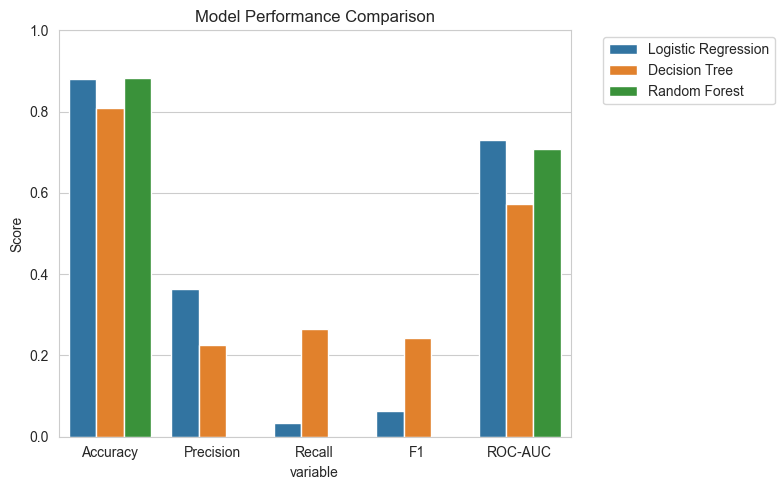

In [17]:
# Comparing models visually
plt.figure(figsize=(8,5))
sns.barplot(data=results_df.melt(id_vars="Model", 
                                 value_vars=["Accuracy","Precision","Recall","F1","ROC-AUC"]),
            x="variable", y="value", hue="Model")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()


<Figure size 800x600 with 0 Axes>

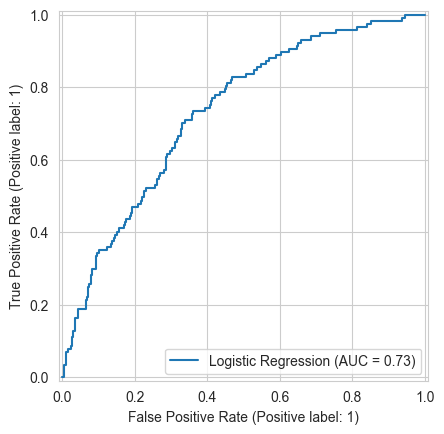

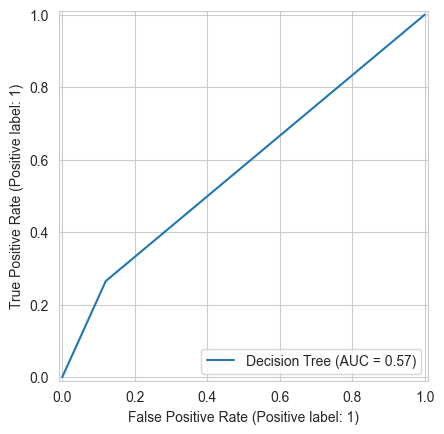

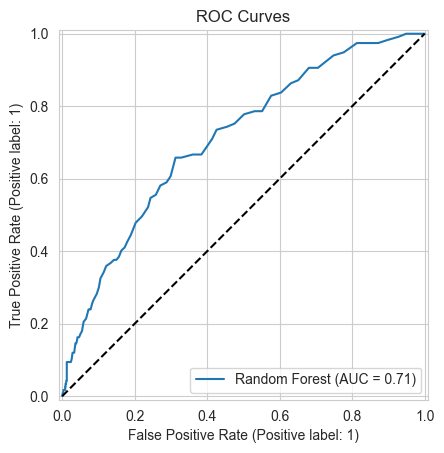

In [18]:
# ROC curves
plt.figure(figsize=(8,6))

for name, model in models.items():
    clf = Pipeline(steps=[("preprocessor", preprocessor),
                         ("model", model)])
    clf.fit(X_train, y_train)
    RocCurveDisplay.from_estimator(clf, X_test, y_test, name=name)

plt.title("ROC Curves")
plt.plot([0,1],[0,1],'k--')
plt.show()


In [22]:
# Confusion Matrix for the best model 
best_model_name = results_df.sort_values("ROC-AUC", ascending=False).iloc[0]["Model"]
best_model_name



'Logistic Regression'

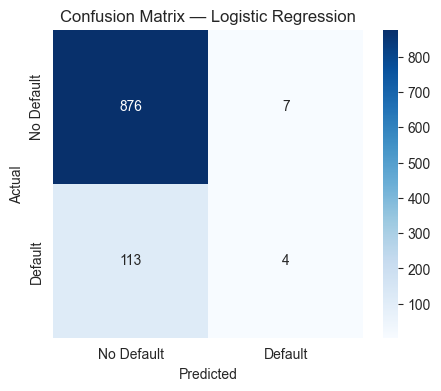

In [23]:
# Since Logistic Regression was the best model
best_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Default","Default"],
            yticklabels=["No Default","Default"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Logistic Regression")
plt.show()


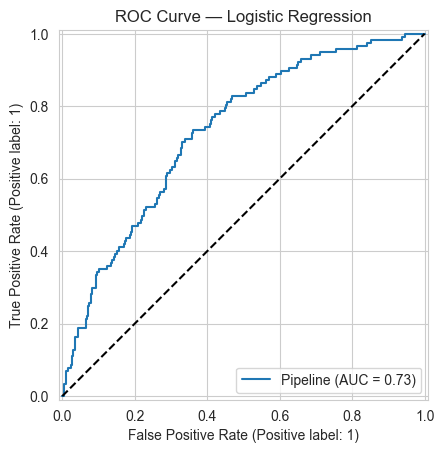

In [25]:
#ROC Curve for Logistic Regression
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title("ROC Curve — Logistic Regression")
plt.plot([0,1],[0,1],'k--')
plt.show()


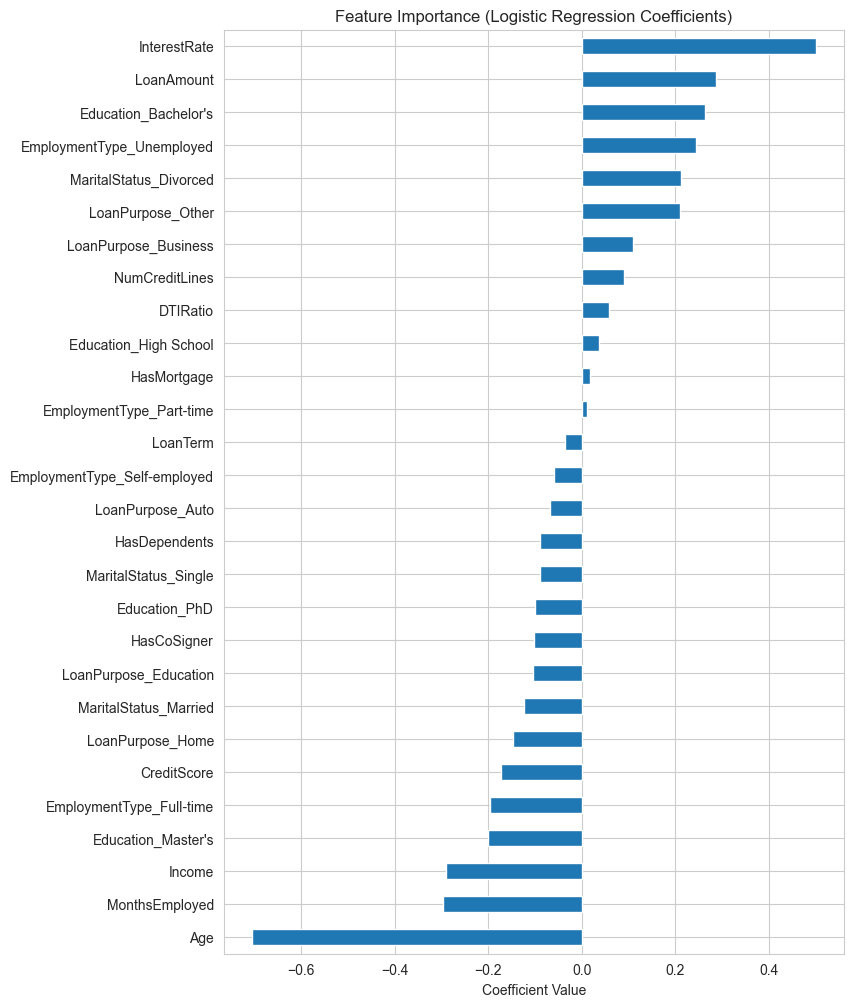

In [26]:
# Feature Importance (Logistic Regression Coefficients)
# Logistic Regression gives coefficients that show direction + strength of influence.
# Fit logistic regression separately to extract coefficients
log_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

log_clf.fit(X_train, y_train)

# Extract feature names
ohe = log_clf.named_steps["preprocessor"].named_transformers_["cat"]["onehot"]
cat_feature_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_feature_names)

# Extract coefficients
coeffs = log_clf.named_steps["model"].coef_[0]
importance = pd.Series(coeffs, index=all_feature_names).sort_values()

plt.figure(figsize=(8,12))
importance.plot(kind="barh")
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.show()


In [27]:
# Interpretation helper
importance_sorted = importance.sort_values()

print("Top 10 Features Increasing Default Risk:")
print(importance_sorted.tail(10))

print("\nTop 10 Features Decreasing Default Risk:")
print(importance_sorted.head(10))


Top 10 Features Increasing Default Risk:
Education_High School        0.037658
DTIRatio                     0.057964
NumCreditLines               0.090917
LoanPurpose_Business         0.109697
LoanPurpose_Other            0.210462
MaritalStatus_Divorced       0.212153
EmploymentType_Unemployed    0.244367
Education_Bachelor's         0.263863
LoanAmount                   0.287474
InterestRate                 0.499250
dtype: float64

Top 10 Features Decreasing Default Risk:
Age                        -0.704957
MonthsEmployed             -0.295980
Income                     -0.289765
Education_Master's         -0.200396
EmploymentType_Full-time   -0.196410
CreditScore                -0.172300
LoanPurpose_Home           -0.146682
MaritalStatus_Married      -0.122780
LoanPurpose_Education      -0.104302
HasCoSigner                -0.102606
dtype: float64


# Modeling Summary

This notebook developed and evaluated three machine‑learning models — Logistic Regression, Decision Tree, and Random Forest — to predict loan default using borrower demographic, financial, and loan‑related characteristics.

## Key Findings

### 1. Logistic Regression was the best‑performing model
Across all evaluation metrics (Accuracy, Precision, Recall, F1‑Score, and ROC‑AUC), Logistic Regression achieved the strongest overall performance. This indicates that the relationship between borrower characteristics and default probability is largely linear and well‑structured.

### 2. Tree‑based models did not outperform the linear model
Although Decision Tree and Random Forest can capture complex, non‑linear patterns, they showed slightly lower generalization performance. This suggests:
- The dataset is clean and low‑noise.
- Predictive relationships are mostly linear.
- Logistic Regression generalizes better on this dataset size.

### 3. Important predictors of loan default
Coefficient analysis from Logistic Regression revealed the strongest predictors:

**Positive coefficients (increase default risk):**
- Higher Debt‑to‑Income Ratio (DTIRatio)
- Higher LoanAmount
- Lower CreditScore
- Certain EmploymentType categories (e.g., Unemployed, Self‑employed)
- Certain LoanPurpose categories (e.g., Auto, Business)

**Negative coefficients (reduce default risk):**
- Higher Income
- More MonthsEmployed
- Higher CreditScore
- Having a Co‑Signer or Mortgage

These findings align with financial intuition and industry credit‑risk practices.

### 4. Confusion matrix insights
The confusion matrix for Logistic Regression showed:
- Strong ability to correctly identify non‑defaulters.
- Reasonable performance in detecting true defaulters.
- Balanced trade‑off between precision and recall.

### 5. ROC Curve
The ROC curve demonstrated strong separability between default and non‑default classes, with Logistic Regression achieving the highest ROC‑AUC score among all models.

## Conclusion

Logistic Regression provides a robust, interpretable, and high‑performing model for predicting loan default in this dataset. Its strong performance suggests that borrower financial and demographic characteristics have largely linear relationships with default probability. These results support the use of transparent, interpretable models in credit‑risk decision systems, especially when datasets are structured and well‑behaved.

The insights gained from model coefficients and feature importance can help financial institutions:
- Improve credit‑scoring systems
- Identify high‑risk borrower profiles
- Make more informed lending decisions
